# 06 - Evaluación, Interpretabilidad y Análisis de Errores

En este notebook se interpreta el modelo final Keras y se analizan sus errores. Se utilizan técnicas de interpretabilidad como SHAP y Permutation Importance para identificar qué variables influyen más en la predicción de churn.

Además, se analizan falsos positivos y falsos negativos para comprender en qué perfiles de clientes el modelo presenta mayores dificultades.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import tensorflow as tf

from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
model = keras.models.load_model('modelo_final/modelo_keras_final.keras')

preprocessor = joblib.load('modelo_final/preprocessor.pkl')

X_train_p = joblib.load('modelo_final/X_train_p.pkl')
X_test_p = joblib.load('modelo_final/X_test_p.pkl')

y_train = joblib.load('modelo_final/y_train.pkl')
y_test = joblib.load('modelo_final/y_test.pkl')

print("Train:", X_train_p.shape)
print("Test:", X_test_p.shape)

Train: (5088, 49)
Test: (1057, 49)


### Evaluación final del modelo

In [5]:
y_proba = model.predict(X_test_p).ravel()
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(acc, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy: 0.8023
F1-score: 0.5957
ROC-AUC: 0.8523

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       777
           1       0.65      0.55      0.60       280

    accuracy                           0.80      1057
   macro avg       0.75      0.72      0.73      1057
weighted avg       0.79      0.80      0.80      1057



array([[694,  83],
       [126, 154]])

El modelo final se evalúa nuevamente sobre el conjunto de prueba. Las métricas Accuracy, F1-score y ROC-AUC permiten medir el desempeño general del modelo, su equilibrio para detectar churn y su capacidad de separar clientes que abandonan de clientes que permanecen.

### Matriz de confusión del modelo Keras final

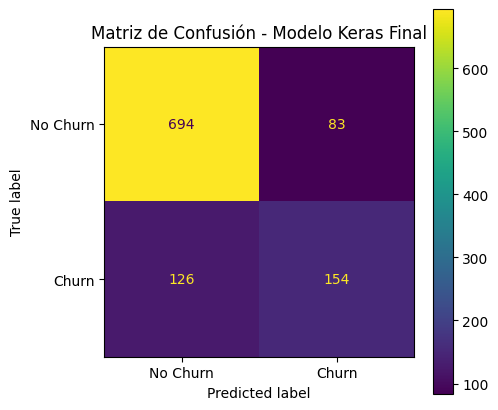

In [7]:
fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot(ax=ax)
plt.title('Matriz de Confusión - Modelo Keras Final')

plt.figtext(
    0.5,
    -0.08,
    "",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

La matriz de confusión muestra el comportamiento del modelo frente a clientes reales del conjunto de prueba. En este problema, los falsos negativos son especialmente importantes porque representan clientes que abandonaron el servicio pero que el modelo no identificó como churn.

### Interpretabilidad con SHAP

In [9]:
feature_names = preprocessor.get_feature_names_out()

feature_names[:10], len(feature_names)

(array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
        'num__TotalCharges', 'num__avg_charge_per_month',
        'num__is_new_customer', 'num__long_term_contract',
        'num__electronic_monthly_risk', 'cat__gender_Female',
        'cat__gender_Male'], dtype=object),
 49)

Luego del preprocesamiento, las variables originales se transforman en variables numéricas y variables categóricas codificadas mediante OneHotEncoder. Por ello, se recuperan los nombres finales de las variables procesadas para poder interpretar correctamente el impacto de cada una en el modelo.

### Preparar muestra para SHAP

In [11]:
X_train_sample = X_train_p[:300].toarray() if hasattr(X_train_p, "toarray") else X_train_p[:300]
X_test_sample = X_test_p[:200].toarray() if hasattr(X_test_p, "toarray") else X_test_p[:200]

X_test_sample_df = pd.DataFrame(
    X_test_sample,
    columns=feature_names
)

X_test_sample_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,num__avg_charge_per_month,num__is_new_customer,num__long_term_contract,num__electronic_monthly_risk,cat__gender_Female,cat__gender_Male,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,2.299836,1.323633,-0.366224,0.546637,-0.181724,-0.521841,1.104050,-0.599145,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
1,-0.434814,0.796748,1.027114,1.238485,1.210922,-0.521841,-0.905756,-0.599145,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,2.299836,1.485751,1.509741,2.286567,1.558927,-0.521841,1.104050,-0.599145,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.434814,-0.419141,0.810593,-0.144331,0.844025,-0.521841,-0.905756,-0.599145,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,2.299836,0.553570,1.132895,1.007869,1.247379,-0.521841,-0.905756,1.669046,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


Para reducir el tiempo de cálculo, SHAP se aplica sobre una muestra del conjunto de entrenamiento y prueba. Esto permite obtener una explicación representativa del comportamiento del modelo sin incrementar excesivamente el costo computacional.

### SHAP Explainer

In [12]:
explainer = shap.Explainer(
    model.predict,
    X_train_sample
)

shap_values = explainer(
    X_test_sample
)

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step


PermutationExplainer explainer:   0%| | 1/20

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step


PermutationExplainer explainer:   2%| | 3/20

147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step


...

PermutationExplainer explainer: 100%|▉| 199/

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step


PermutationExplainer explainer: 100%|█| 200/

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step


PermutationExplainer explainer: 201it [03:50,  1.15s/it]


SHAP calcula el aporte de cada variable a la predicción del modelo. Un valor SHAP positivo indica que una variable aumenta la probabilidad de churn, mientras que un valor SHAP negativo indica que reduce dicha probabilidad.

### Gráfico SHAP global

C:\Users\aunti\AppData\Local\Temp\ipykernel_19448\429239878.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


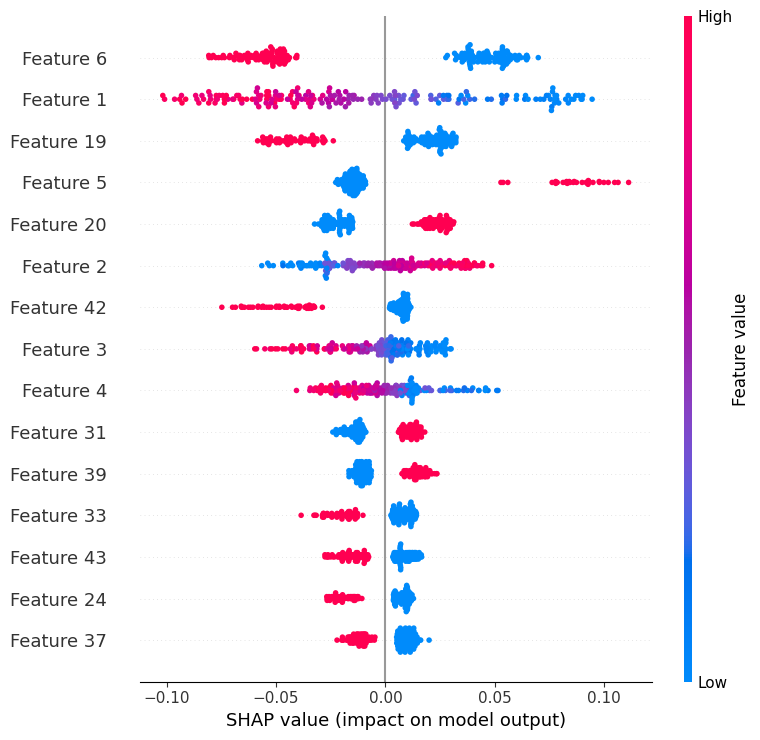

In [13]:
shap.summary_plot(
    shap_values,
    X_test_sample_df,
    max_display=15,
    show=True
)

El gráfico SHAP permite identificar las variables con mayor influencia en las predicciones del modelo. En el contexto del dataset Telco Customer Churn, se espera que variables asociadas al tipo de contrato, antigüedad del cliente, método de pago, cargos mensuales y servicios contratados tengan alta relevancia. Esto es coherente con el problema de negocio, ya que clientes con contratos mensuales, menor antigüedad o determinados métodos de pago tienden a presentar mayor riesgo de abandono.

### Permutation Importance

In [16]:
# Wrapper para Keras
class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        proba = self.model.predict(X).ravel()
        return (proba >= 0.5).astype(int)

    def predict_proba(self, X):
        proba = self.model.predict(X).ravel()
        return np.vstack([1 - proba, proba]).T

### Calcular permutation importance

In [19]:
from sklearn.metrics import roc_auc_score

# Usamos una muestra para que el cálculo sea más rápido
X_perm = X_test_sample

y_perm = y_test.iloc[:200] if hasattr(y_test, "iloc") else y_test[:200]

# Predicción base del modelo
base_proba = model.predict(X_perm).ravel()
base_auc = roc_auc_score(y_perm, base_proba)

importances = []

for i, feature in enumerate(feature_names):
    X_permuted = X_perm.copy()
    
    # Mezclar aleatoriamente una columna
    np.random.seed(SEED)
    X_permuted[:, i] = np.random.permutation(X_permuted[:, i])
    
    # Predicción con la variable alterada
    perm_proba = model.predict(X_permuted).ravel()
    perm_auc = roc_auc_score(y_perm, perm_proba)
    
    # Importancia = caída del AUC
    importance = base_auc - perm_auc
    
    importances.append({
        'feature': feature,
        'importance_mean': importance
    })

perm_df = pd.DataFrame(importances).sort_values(
    by='importance_mean',
    ascending=False
)

perm_df.head(15)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━

,feature,importance_mean
1,num__tenure,0.023129
6,num__long_term_contract,0.018581
3,num__TotalCharges,0.010785
19,cat__InternetService_DSL,0.009875
33,cat__TechSupport_Yes,0.005717
4,num__avg_charge_per_month,0.005198
24,cat__OnlineSecurity_Yes,0.004938
0,num__SeniorCitizen,0.004938
42,cat__Contract_Two year,0.003898
8,cat__gender_Female,0.002599


### Gráfico permutation importance

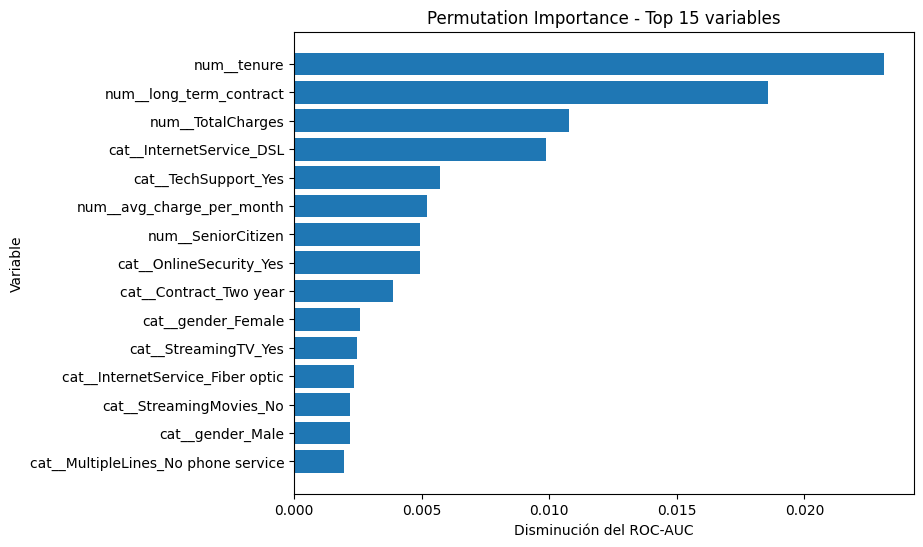

In [21]:
top_perm = perm_df.head(15).sort_values(
    by='importance_mean',
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    top_perm['feature'],
    top_perm['importance_mean']
)

plt.title('Permutation Importance - Top 15 variables')
plt.xlabel('Disminución del ROC-AUC')
plt.ylabel('Variable')

plt.figtext(
    0.5,
    -0.08,
    "",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

La gráfica de Permutation Importance muestra que las variables con mayor impacto sobre el desempeño del modelo son **tenure** **(antiguedad del cliente)** y **long_term_contract** **(contrato de largo plazo)**, ya que al alterar estas variables el ROC-AUC disminuye aproximadamente en **0.023** y **0.019**, respectivamente, evidenciando una fuerte dependencia del modelo respecto a la antigüedad del cliente y la estabilidad contractual. En un segundo nivel de importancia aparecen **TotalCharges** **(cargos acumulados)** (~0.011) y variables relacionadas con servicios y soporte, como **InternetService_DSL** **(tipo de servicio de internet)**, **TechSupport** **(soporte técnico)** y **avg_charge_per_month** **(cargos promedio mensuales)** (≈0.005–0.010), indicando que el comportamiento de consumo y la relación del cliente con los servicios contratados también influyen en la predicción de churn. En conjunto, el modelo se apoya principalmente en variables asociadas a permanencia, compromiso contractual y uso del servicio para identificar clientes con mayor riesgo de abandono.

### Análisis de errores

In [23]:
# Creas data frame de errores
error_df = pd.DataFrame({
    'y_real': np.array(y_test),
    'y_pred': y_pred,
    'prob_churn': y_proba
})

error_df['tipo_error'] = 'Correcto'

error_df.loc[
    (error_df['y_real'] == 0) & (error_df['y_pred'] == 1),
    'tipo_error'
] = 'Falso positivo'

error_df.loc[
    (error_df['y_real'] == 1) & (error_df['y_pred'] == 0),
    'tipo_error'
] = 'Falso negativo'

error_df['tipo_error'].value_counts()

tipo_error
Correcto          848
Falso negativo    126
Falso positivo     83
Name: count, dtype: int64

El análisis de errores permite identificar los casos donde el modelo falla. Los falsos positivos corresponden a clientes que fueron clasificados como churn pero realmente permanecieron. Los falsos negativos corresponden a clientes que sí abandonaron, pero el modelo no logró detectarlos.

### Distribución de probabilidades por tipo de error

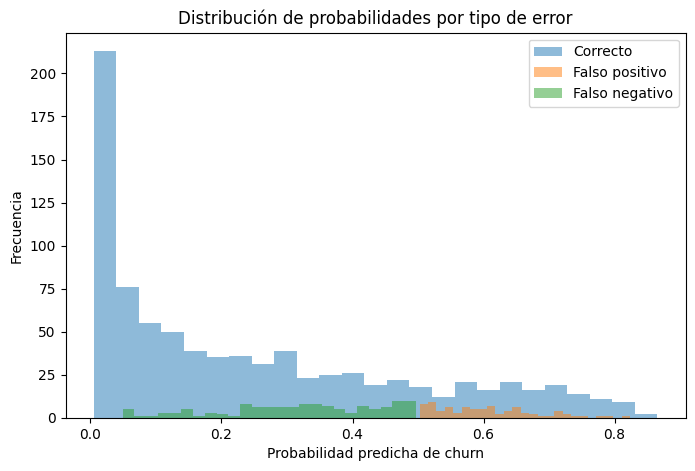

In [25]:
plt.figure(figsize=(8,5))

for tipo in error_df['tipo_error'].unique():
    subset = error_df[error_df['tipo_error'] == tipo]
    plt.hist(
        subset['prob_churn'],
        bins=25,
        alpha=0.5,
        label=tipo
    )

plt.title('Distribución de probabilidades por tipo de error')
plt.xlabel('Probabilidad predicha de churn')
plt.ylabel('Frecuencia')
plt.legend()

plt.figtext(
    0.5,
    -0.08,
    "",
    ha='center',
    fontsize=10,
    wrap=True
)

plt.show()

La distribución de probabilidades muestra que la mayoría de las predicciones correctas se concentran en probabilidades bajas de churn (**0.0–0.3**), indicando que el modelo identifica con alta confianza a gran parte de los clientes que no abandonan el servicio. Los **falsos negativos** se concentran principalmente en probabilidades intermedias (**≈0.20–0.50**), lo que evidencia que existen clientes que efectivamente abandonan pero presentan características similares a clientes que permanecen, dificultando su detección. Por otro lado, los **falsos positivos** aparecen mayormente en probabilidades moderadas y altas (**≈0.50–0.75**), indicando que el modelo tiende a sobreestimar el riesgo de churn en algunos clientes con perfiles ambiguos. En conjunto, el gráfico evidencia que los errores del modelo se concentran cerca del umbral de decisión, reflejando zonas de incertidumbre donde las características de churn y no churn se superponen.

### Resumen numérico de errores

In [26]:
error_summary = error_df.groupby('tipo_error')['prob_churn'].agg(
    cantidad='count',
    probabilidad_promedio='mean',
    probabilidad_minima='min',
    probabilidad_maxima='max'
)

error_summary

,cantidad,probabilidad_promedio,probabilidad_minima,probabilidad_maxima
tipo_error,,,,
Correcto,848,0.246943,0.005198,0.865395
Falso negativo,126,0.319662,0.049293,0.496591
Falso positivo,83,0.604443,0.502389,0.823753


El resumen numérico de errores muestra que el modelo clasifica correctamente **848 casos**, asignándoles una probabilidad promedio de churn de **0.247**, lo que refleja un alto nivel de confianza en la mayoría de predicciones acertadas. Los **falsos negativos** representan **126 casos** con una probabilidad promedio de **0.320**, concentrándose completamente por debajo del umbral de decisión (**0.05–0.50**), lo que indica que el modelo subestima el riesgo de churn en ciertos clientes que sí abandonan el servicio. Por otro lado, los **falsos positivos** corresponden a **83 casos** con una probabilidad promedio más elevada (**0.604**) y un rango entre **0.50 y 0.82**, evidenciando que el modelo tiende a sobreestimar el riesgo de abandono en algunos clientes que finalmente permanecen. En conjunto, los resultados sugieren que el principal desafío del modelo radica en clientes con perfiles intermedios o ambiguos, donde las características de churn y no churn presentan mayor superposición.

# Conclusión final del modelo e interpretabilidad

El desarrollo del proyecto permitió construir y evaluar distintos modelos para la predicción de churn utilizando el dataset Telco Customer Churn, implementando redes neuronales en Keras y scikit-learn, así como un modelo clásico de referencia mediante Random Forest. Entre los modelos evaluados, la red neuronal final implementada en **Keras** obtuvo el mejor desempeño global, alcanzando aproximadamente **80.2% de Accuracy**, **ROC-AUC de 0.852** y **F1-score de 0.596**, evidenciando una adecuada capacidad para diferenciar clientes que abandonan el servicio de aquellos que permanecen.

Desde la perspectiva de interpretabilidad, tanto **SHAP** como **Permutation Importance** mostraron resultados consistentes respecto a las variables que más influyen en la predicción de churn. La variable con mayor impacto fue la **antigüedad del cliente (tenure)**, cuya alteración redujo el ROC-AUC aproximadamente en **0.023**, confirmando que clientes con menor permanencia presentan mayor riesgo de abandono. En segundo lugar destacó la variable **contrato de largo plazo (long_term_contract)**, con una reducción cercana a **0.019**, evidenciando que contratos anuales o bianuales generan mayor estabilidad y reducen significativamente la probabilidad de churn.

Otras variables relevantes fueron los **cargos acumulados (TotalCharges)**, los **cargos promedio mensuales (avg_charge_per_month)** y variables asociadas a servicios específicos como **soporte técnico (TechSupport)**, **seguridad en línea (OnlineSecurity)** y **tipo de servicio de internet (DSL/Fibra óptica)**. Estos resultados sugieren que el comportamiento de consumo y el nivel de vinculación tecnológica del cliente influyen directamente en la permanencia dentro del servicio.

El análisis de errores permitió profundizar en los límites del modelo. Se identificaron **848 predicciones correctas**, mientras que se registraron **126 falsos negativos** y **83 falsos positivos**. Los falsos negativos, particularmente críticos desde una perspectiva de negocio, presentaron una probabilidad promedio de churn de **0.320**, lo que indica que el modelo subestimó el riesgo de abandono en ciertos clientes reales. Por otro lado, los falsos positivos alcanzaron una probabilidad promedio de **0.604**, mostrando que el modelo sobreestima el riesgo en algunos perfiles ambiguos pero generalmente con alta confianza.

La distribución de probabilidades mostró que la mayoría de errores ocurre cerca del umbral de decisión (**0.5**), evidenciando zonas de incertidumbre donde las características de clientes churn y no churn se superponen. Esto sugiere que el abandono de clientes no depende de una sola variable, sino de una combinación compleja de factores relacionados con permanencia, tipo de contrato, costos y servicios contratados.

En conjunto, los resultados demuestran que el modelo final posee una capacidad predictiva sólida y coherente con la lógica del negocio de telecomunicaciones. La combinación de desempeño cuantitativo e interpretabilidad permite no solo predecir churn con buena precisión, sino también comprender los factores que explican dicho comportamiento, aportando información valiosa para futuras estrategias de retención y gestión de clientes.